In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('zomato.csv')

In [4]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
df.nunique()

url                            51717
address                        11495
name                            8792
online_order                       2
book_table                         2
rate                              64
votes                           2328
phone                          14926
location                          93
rest_type                         93
dish_liked                      5271
cuisines                        2723
approx_cost(for two people)       70
reviews_list                   22513
menu_item                       9098
listed_in(type)                    7
listed_in(city)                   30
dtype: int64

In [7]:
df2 = df.copy()

In [8]:
df2.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [9]:
df2.drop(['url','address','phone','reviews_list','menu_item','location','dish_liked','cuisines'],inplace=True,axis=1)

In [10]:
df2.head()

,name,online_order,book_table,rate,votes,rest_type,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Casual Dining,800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Casual Dining,800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Cafe, Casual Dining",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Quick Bites,300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Casual Dining,600,Buffet,Banashankari


In [11]:
df2 = df2.rename(columns={"name":"restaurant_name","rate":"rating",
                          "approx_cost(for two people)":"cost_for_two","listed_in(type)":"type",
                          "listed_in(city)":"location","book_table":"reservations","online_order":"online"})

df2.head()

,restaurant_name,online,reservations,rating,votes,rest_type,cost_for_two,type,location
0,Jalsa,Yes,Yes,4.1/5,775,Casual Dining,800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Casual Dining,800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Cafe, Casual Dining",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Quick Bites,300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Casual Dining,600,Buffet,Banashankari


In [12]:
print(df2.shape)

print('Duplicate values:',df2.duplicated().sum())

(51717, 9)
Duplicate values: 127


In [13]:
df2.drop_duplicates(inplace=True)

print(df2.shape)


(51590, 9)


In [14]:
df2.isnull().sum()

restaurant_name       0
online                0
reservations          0
rating             7738
votes                 0
rest_type           227
cost_for_two        344
type                  0
location              0
dtype: int64

In [15]:
df2['rating'] = df2['rating'].str.split('/5').str[0].str.strip()

df2['rating'].unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', 'NEW', '2.9', '3.5', nan,
       '2.6', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3', '-',
       '4.8', '4.9', '2.1', '2.0', '1.8'], dtype=object)

In [16]:
df2.drop(df2[(df2['rating'] == 'NEW') | (df2['rating'] == '-')].index, inplace=True)

In [17]:
df2['rating'] = df2['rating'].astype(float)
                                     
df2['rating'].dtype

dtype('float64')

In [18]:
df2['rating'] = df2['rating'].fillna(df2['rating'].mean())

In [19]:
print('Rating Description: ')
df2['rating'].describe()


Rating Description: 


count    49327.000000
mean         3.700151
std          0.404431
min          1.800000
25%          3.500000
50%          3.700151
75%          4.000000
max          4.900000
Name: rating, dtype: float64

In [20]:
df2['rest_type'] = df2['rest_type'].fillna('Other')



In [21]:
df2['cost_for_two'] = df2['cost_for_two'].str.replace(',','')

df2['cost_for_two'] = pd.to_numeric(df2['cost_for_two'])

In [22]:
df2['cost_for_two'].unique()


array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199., 1100., 1600.,  230.,  130.,
         80.,   50.,  190., 1700.,   nan,  180., 1350., 2200., 1400.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  240., 6000., 1050., 2300., 4100., 5000.,
       3700., 1650., 2700., 4500.,  140.,  360.])

In [23]:
df2['cost_for_two'] = df2['cost_for_two'].fillna(df2['cost_for_two'].mean())

print('cost_for_two Description: ')


df2['cost_for_two'].describe()



cost_for_two Description: 


count    49327.000000
mean       561.046889
std        441.711796
min         40.000000
25%        300.000000
50%        400.000000
75%        700.000000
max       6000.000000
Name: cost_for_two, dtype: float64

In [24]:
df2.isnull().sum()


restaurant_name    0
online             0
reservations       0
rating             0
votes              0
rest_type          0
cost_for_two       0
type               0
location           0
dtype: int64

In [25]:
pd.crosstab(df2['type'],df2['location'], margins=True)

location,BTM,Banashankari,Bannerghatta Road,Basavanagudi,Bellandur,Brigade Road,Brookefield,Church Street,Electronic City,Frazer Town,...,MG Road,Malleshwaram,Marathahalli,New BEL Road,Old Airport Road,Rajajinagar,Residency Road,Sarjapur Road,Whitefield,All
type,,,,,,,,,,,,,,,,,,,,,
Buffet,37,7,16,14,29,57,32,60,21,14,...,54,22,32,4,26,17,59,26,0,862
Cafes,97,24,38,44,26,80,33,84,20,45,...,76,29,29,29,51,22,75,28,37,1645
Delivery,1688,446,847,607,623,668,798,628,488,627,...,717,535,831,368,683,441,601,625,756,24651
Desserts,195,56,111,104,74,130,78,131,66,83,...,137,83,94,42,105,100,127,82,108,3449
Dine-out,991,282,473,416,359,627,451,679,467,348,...,634,355,596,268,423,431,648,419,597,16988
Drinks & nightlife,42,8,15,12,18,76,14,79,20,11,...,73,23,22,7,38,20,76,21,36,1066
Pubs and bars,48,0,0,0,18,76,0,76,20,16,...,74,20,0,7,41,24,0,20,35,666
All,3098,823,1500,1197,1147,1714,1406,1737,1102,1144,...,1765,1067,1604,725,1367,1055,1586,1221,1569,49327


In [26]:
pd.crosstab(df2['online'],df2['location'], margins=True)

location,BTM,Banashankari,Bannerghatta Road,Basavanagudi,Bellandur,Brigade Road,Brookefield,Church Street,Electronic City,Frazer Town,...,MG Road,Malleshwaram,Marathahalli,New BEL Road,Old Airport Road,Rajajinagar,Residency Road,Sarjapur Road,Whitefield,All
online,,,,,,,,,,,,,,,,,,,,,
No,1073,290,555,427,373,810,507,894,607,448,...,927,412,679,318,590,522,893,466,743,20072
Yes,2025,533,945,770,774,904,899,843,495,696,...,838,655,925,407,777,533,693,755,826,29255
All,3098,823,1500,1197,1147,1714,1406,1737,1102,1144,...,1765,1067,1604,725,1367,1055,1586,1221,1569,49327


In [27]:
pd.crosstab(df2['online'],df2['type'], margins=True)

type,Buffet,Cafes,Delivery,Desserts,Dine-out,Drinks & nightlife,Pubs and bars,All
online,,,,,,,,
No,515,771,6577,1857,9037,834,481,20072
Yes,347,874,18074,1592,7951,232,185,29255
All,862,1645,24651,3449,16988,1066,666,49327


In [28]:
rating_categories = df2['rating']
rating_categories = rating_categories.dropna()

bins = [1,2,3,4,5]
binlabels = ['Poor', 'Unsatisfactory', 'Satisfactory', 'Outstanding']

categories = pd.cut(rating_categories,bins,labels = binlabels)
categories.head(10)

0     Outstanding
1     Outstanding
2    Satisfactory
3    Satisfactory
4    Satisfactory
5    Satisfactory
6    Satisfactory
7     Outstanding
8    Satisfactory
9     Outstanding
Name: rating, dtype: category
Categories (4, object): ['Poor' < 'Unsatisfactory' < 'Satisfactory' < 'Outstanding']

In [29]:
df2['rating_categories'] = categories

df2.head()

,restaurant_name,online,reservations,rating,votes,rest_type,cost_for_two,type,location,rating_categories
0,Jalsa,Yes,Yes,4.1,775,Casual Dining,800.0,Buffet,Banashankari,Outstanding
1,Spice Elephant,Yes,No,4.1,787,Casual Dining,800.0,Buffet,Banashankari,Outstanding
2,San Churro Cafe,Yes,No,3.8,918,"Cafe, Casual Dining",800.0,Buffet,Banashankari,Satisfactory
3,Addhuri Udupi Bhojana,No,No,3.7,88,Quick Bites,300.0,Buffet,Banashankari,Satisfactory
4,Grand Village,No,No,3.8,166,Casual Dining,600.0,Buffet,Banashankari,Satisfactory


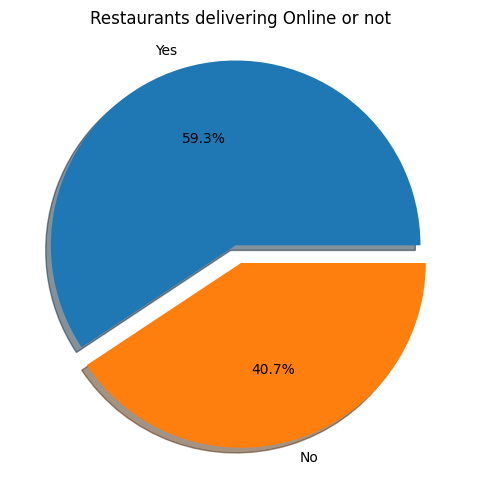

In [30]:
size = df2['online'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(size, labels= size.index, autopct='%1.1f%%', explode=[0.1,0], shadow=True)

plt.title('Restaurants delivering Online or not')
plt.show()

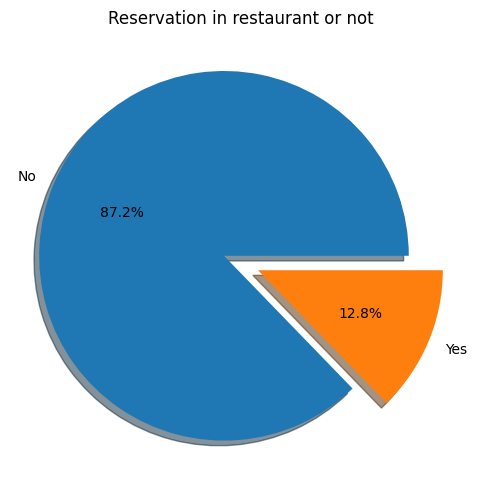

In [31]:
size = df2['reservations'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(size, labels= size.index, autopct='%1.1f%%', explode=[0.1,0.1], shadow=True)

plt.title('Reservation in restaurant or not')
plt.show()

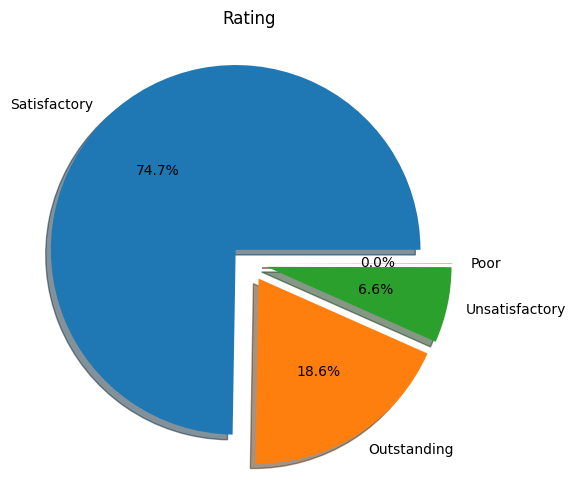

In [32]:
size = df2['rating_categories'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(size, labels= size.index, autopct='%1.1f%%', explode=[0.1,0.1,0.1,0.1], shadow=True)

plt.title('Rating')
plt.show()

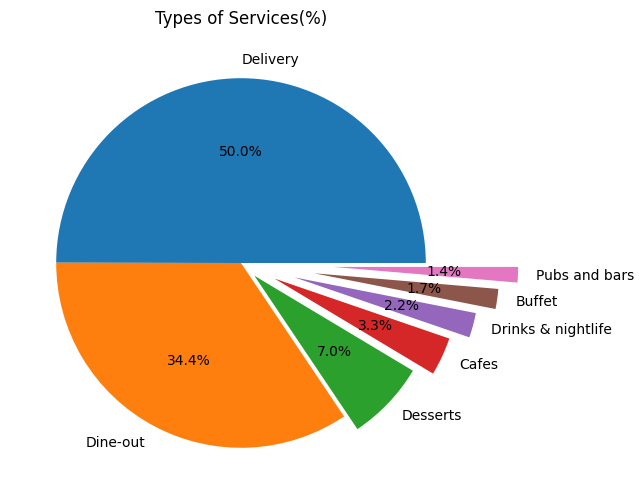

In [33]:
size = df2['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(size , labels=size.index,autopct='%1.1f%%' ,explode=[0,0,0.1,0.2,0.3,0.4,0.5])

plt.title('Types of Services(%)')
plt.show()

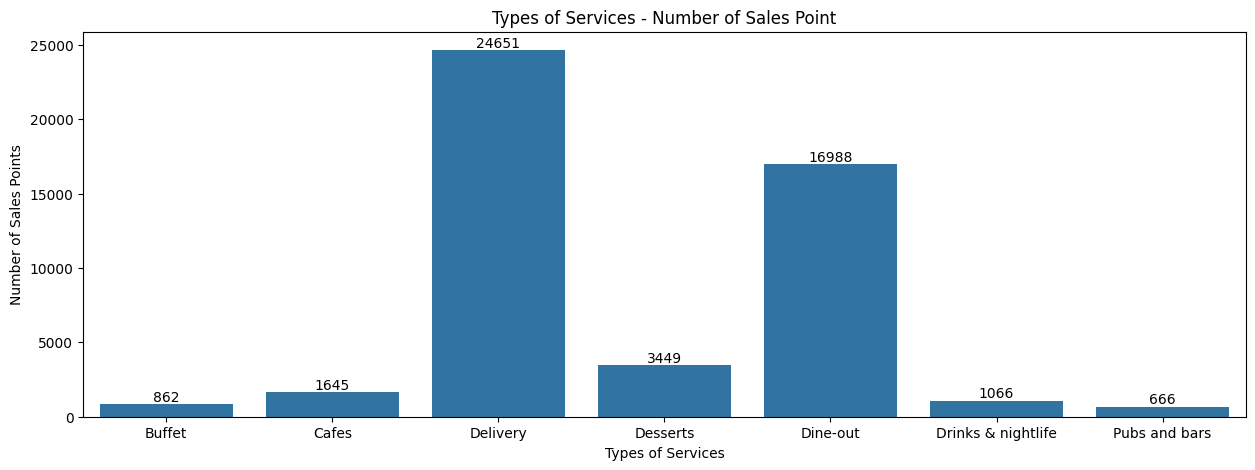

In [34]:
plt.figure(figsize=(15,5))
ax = sns.countplot(x='type',data=df2)
ax.bar_label(ax.containers[0])

plt.title("Types of Services - Number of Sales Point")
plt.xlabel("Types of Services")
plt.ylabel("Number of Sales Points")
plt.show()

<Axes: xlabel='type', ylabel='rating'>

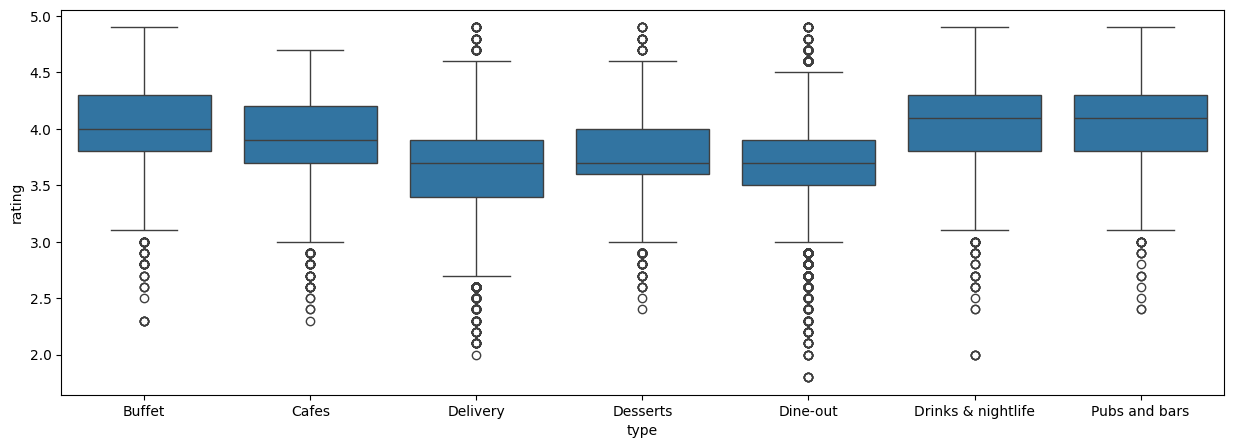

In [35]:
plt.figure(figsize=(15,5))
sns.boxplot(x='type',y='rating',data=df2)



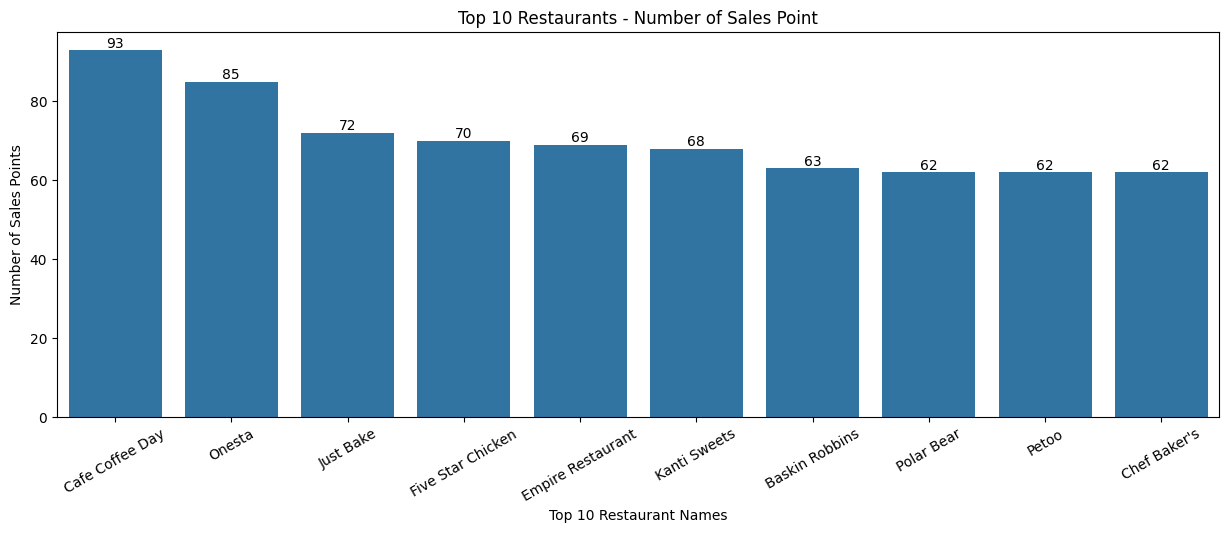

In [36]:
plt.figure(figsize=(15,5))
size = df2['restaurant_name'].value_counts()[:10]

ax = sns.barplot(x=size.index,y=size.values)
ax.bar_label(ax.containers[0])

plt.title("Top 10 Restaurants - Number of Sales Point")
plt.xlabel("Top 10 Restaurant Names")
plt.ylabel("Number of Sales Points")
plt.xticks(rotation=30)
plt.show()

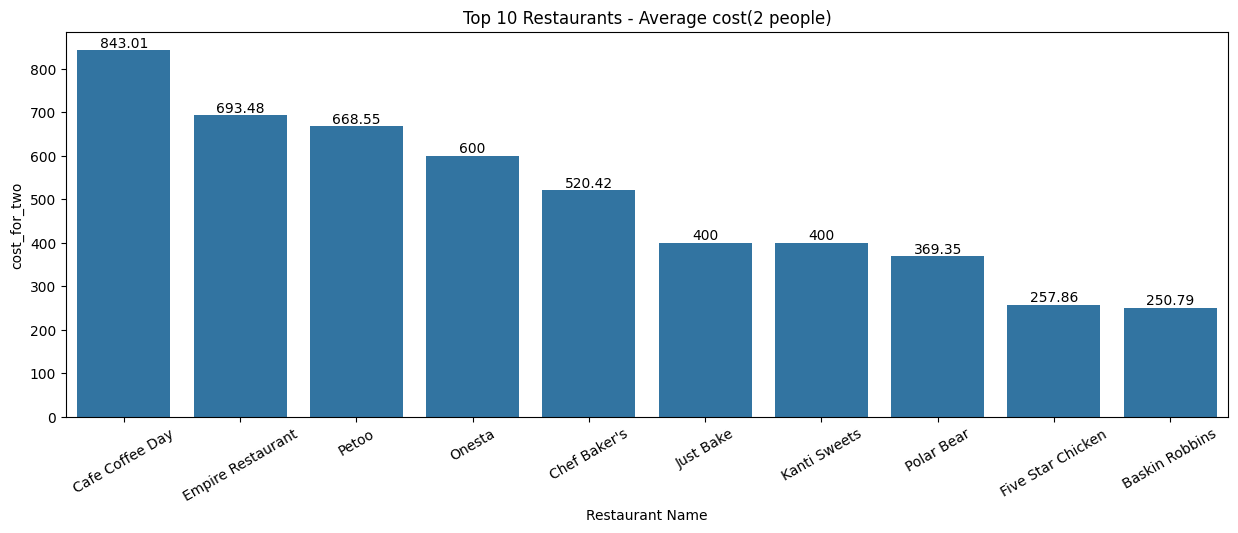

In [37]:
res_cost = df2['cost_for_two'].groupby(df2['restaurant_name'], sort=True)
dict_1 = {}

for i,j in df2['restaurant_name'].value_counts()[:10].to_dict().items():
    dict_1[i]=round(res_cost.get_group(i).mean(),2)

cost_df = pd.DataFrame(list(dict_1.items()),columns=['Restaurant Name',"cost_for_two"])

plt.figure(figsize=(15,5))
ax = sns.barplot(data = cost_df.sort_values(by=['cost_for_two'],ascending=False),
            y = 'cost_for_two',x= 'Restaurant Name')

ax.bar_label(ax.containers[0])

plt.title('Top 10 Restaurants - Average cost(2 people)')
plt.xticks(rotation = 30)
plt.show()

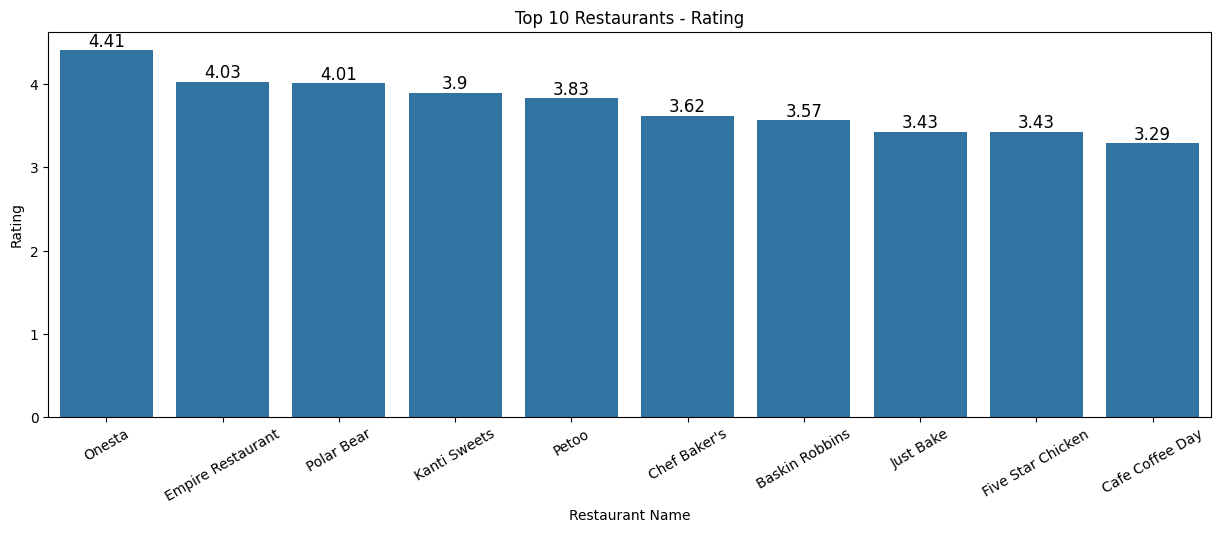

In [38]:
res_rating = df2['rating'].groupby(df2['restaurant_name'],sort=True)
dict_1={}
for i,j in df2['restaurant_name'].value_counts()[:10].to_dict().items():
    dict_1[i]=round(res_rating.get_group(i).mean(),2)
cost_df = pd.DataFrame(list(dict_1.items()),columns=['Restaurant Name',"Rating"])


plt.figure(figsize=(15,5))
ax = sns.barplot(data = cost_df.sort_values(by=['Rating'],ascending=False),
            y = 'Rating',x = 'Restaurant Name')
            
ax.bar_label(ax.containers[0], fontsize=12)
plt.title('Top 10 Restaurants - Rating')
plt.xticks(rotation=30)
plt.show()

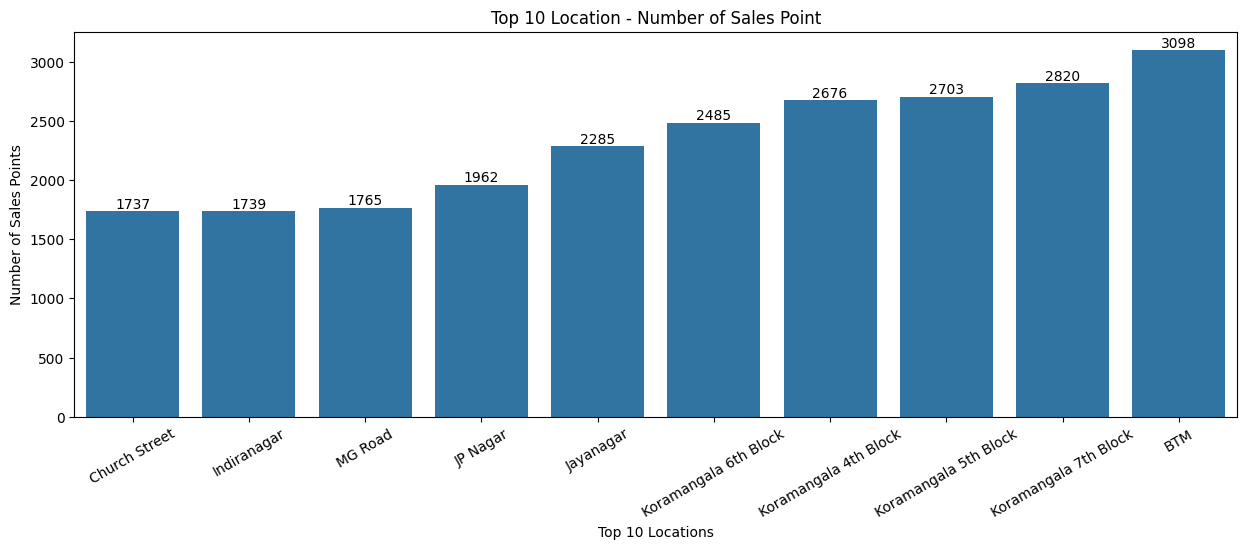

In [39]:
plt.figure(figsize=(15,5)) 
size = df2['location'].value_counts()[:10].sort_values()

ax = sns.barplot(x=size.index,y=size)
ax.bar_label(ax.containers[0])

plt.title("Top 10 Location - Number of Sales Point")
plt.ylabel("Number of Sales Points")
plt.xlabel("Top 10 Locations")
plt.xticks(rotation=30)
plt.show()

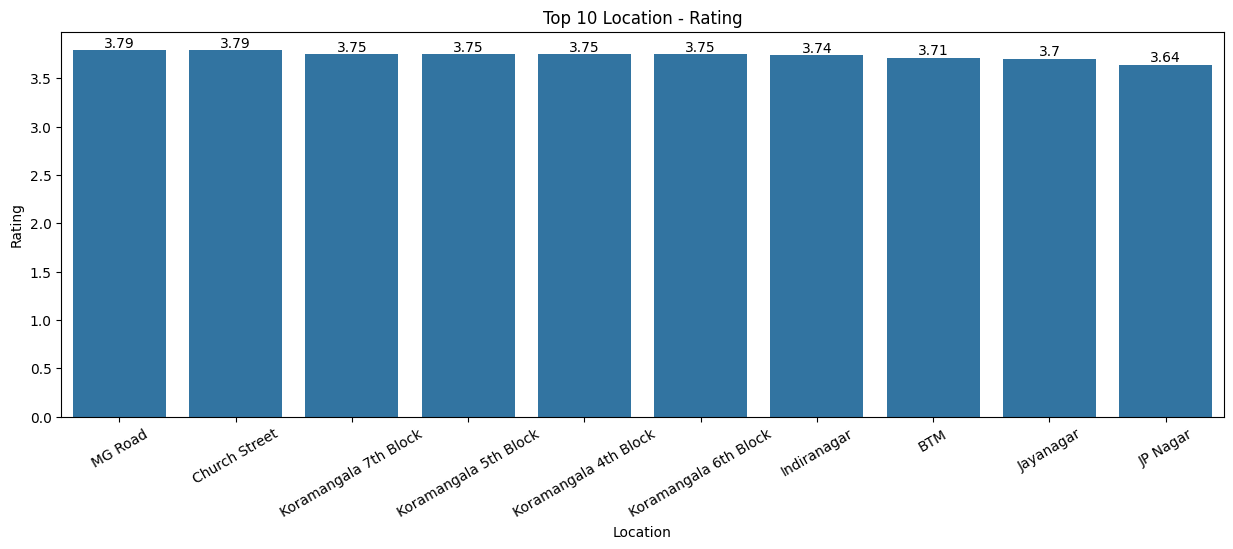

In [40]:
loc_rating = df2['rating'].groupby(df2['location'],sort=True)
dict_1={}
for i,j in df2['location'].value_counts()[:10].to_dict().items():
    dict_1[i]=round(loc_rating.get_group(i).mean(),2)
cost_df = pd.DataFrame(list(dict_1.items()),columns=['Location',"Rating"])

plt.figure(figsize=(15,5))
ax = sns.barplot(data = cost_df.sort_values(by=['Rating'],ascending=False),
            y = 'Rating',x = 'Location')
ax.bar_label(ax.containers[0])

plt.title('Top 10 Location - Rating')
plt.xticks(rotation=30)
plt.show()

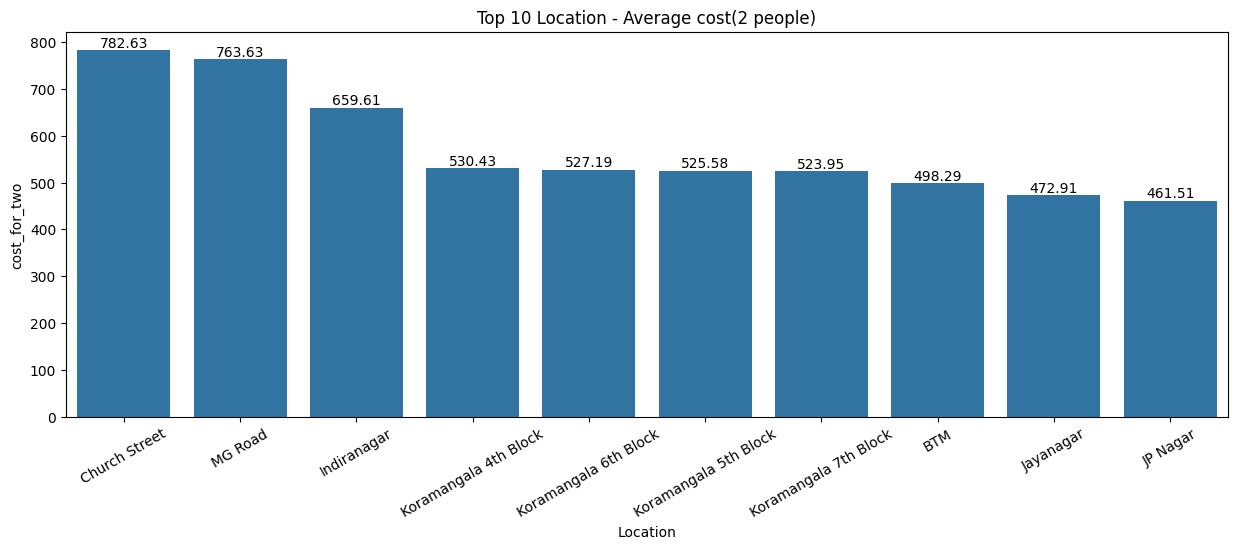

In [41]:
loc_cost = df2['cost_for_two'].groupby(df2['location'],sort=True)
dict_1={}
for i,j in df2['location'].value_counts()[:10].to_dict().items():
    dict_1[i]=round(loc_cost.get_group(i).mean(),2)
cost_df = pd.DataFrame(list(dict_1.items()),columns=['Location',"cost_for_two"])



plt.figure(figsize=(15,5))
ax = sns.barplot(data = cost_df.sort_values(by=['cost_for_two'],ascending=False),
            y = 'cost_for_two',x = 'Location')
ax.bar_label(ax.containers[0])
plt.title('Top 10 Location - Average cost(2 people)')
plt.xticks(rotation = 30)
plt.show()

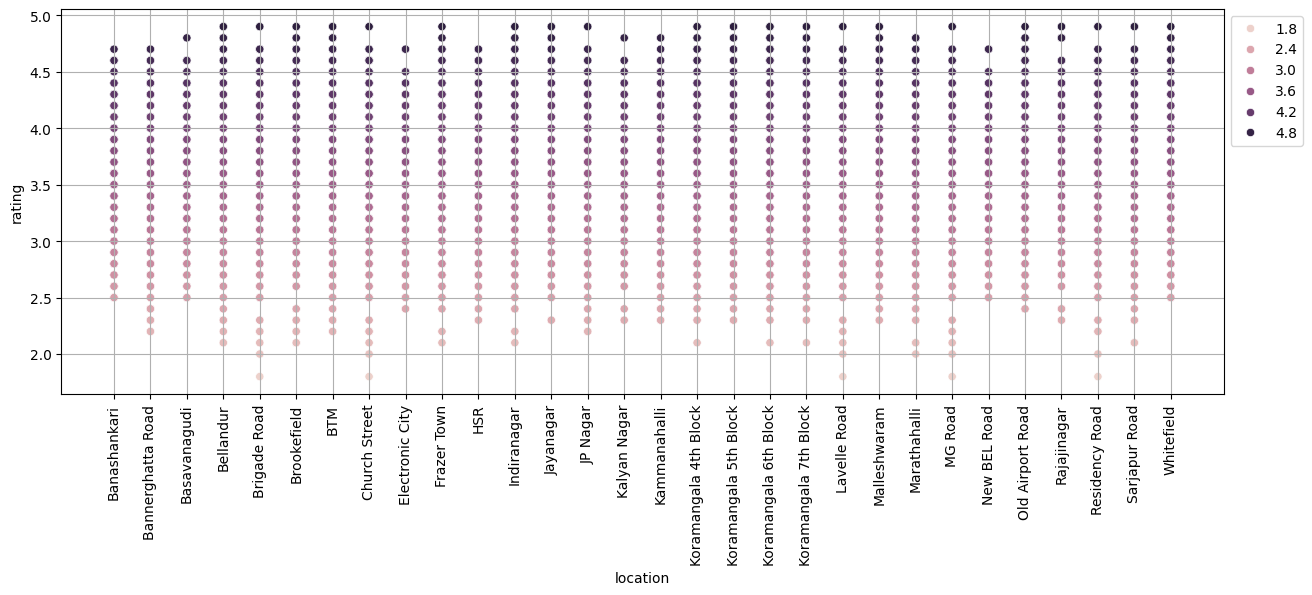

In [42]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=df2, x='location', y='rating', hue = 'rating')

plt.xticks(rotation=90)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.show()

In [43]:
df.to_csv('zomato_compressed.csv.gz', index=False, compression='gzip')
